# ICA: overlay the top 3 decoding-relevant components on one brain

This notebook implements the figure idea discussed with your supervisor:

- one **combined brain plot** with the **top 3 ICA components** overlaid in three colors
- **whole-map component weights** drive the overlay opacity/intensity
- one **pie chart per component** showing that component's Yeo-7 network distribution
- pie **size scales with decoding relevance**
- optional **standalone repeated-CV AUC** is shown next to each pie for reference

**Important distinction**
- **pie size** = decoding relevance of the component
- **pie slices** = Yeo-7 spatial composition of that component
- **brain overlay opacity** = spatial magnitude of that component map

By default, the notebook ranks components by **mean decoding importance** from the repeated-CV full model and uses the **whole map**, not the top 20%.


## 1. Configuration

In [1]:

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, to_rgba
import numpy as np
import pandas as pd

from nilearn import datasets, plotting
from nilearn.image import index_img, load_img, new_img_like, resample_to_img
from scipy.ndimage import binary_erosion

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ------------------------------
# User settings
# ------------------------------
ROOT = Path(r"/Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA")
K = 20

LABELS_CSV   = ROOT / "proficiency_labels.csv"
FEAT_STATIC  = ROOT / f"features_static_nonZ_K{K}.csv"
FEAT_LN_CONN = ROOT / f"features_ln_conn_pearsonZ_K{K}.csv"
COMPONENT_NIFTI = ROOT / f"group_ica_K{K}_components.nii.gz"

OUTDIR = ROOT / "paper_figures_ica_overlay_top3_component_pies"
OUTDIR.mkdir(parents=True, exist_ok=True)

# Decoding settings
N_SPLITS = 5
N_REPEATS = 200
SEED = 42
TOP_M = 4           # for foldwise connectivity augmentation in the full model
TOP_N_TO_PLOT = 3   # number of components to show in the final figure
CLASS_WEIGHT = "balanced"

# Whole-map overlay settings
ERODE_ITERS = 1
USE_ABSOLUTE_COMPONENT_MAPS = True
DISPLAY_MODE = "lyrz"
DPI = 400
FIGSIZE = (17, 9)

# Layout
BRAIN_AXES_RECT = (0.05, 0.18, 0.48, 0.68)  # x, y, w, h in figure fraction
PIE_X = 0.64
PIE_WIDTH = 0.27
PIE_HEIGHT = 0.18
PIE_BOTTOMS = [0.68, 0.42, 0.16]

# Overlay colors for the three top-ranked components
OVERLAY_COLORS = {
    0: "#1f77b4",   # blue
    1: "#2ca02c",   # green
    2: "#d627a5",   # magenta
}

# How to scale pie size:
# "mean_importance" -> size by component contribution in full model
# "standalone_auc"  -> size by repeated-CV AUC from that component alone
PIE_SIZE_BY = "mean_importance"
PIE_RADIUS_MIN = 0.62
PIE_RADIUS_MAX = 1.10

# Figure text
SHOW_STANDALONE_AUC = True
SHOW_IMPORTANCE_TEXT = True

print("ROOT:", ROOT)
print("Static features:", FEAT_STATIC)
print("Connectivity features:", FEAT_LN_CONN)
print("Component image:", COMPONENT_NIFTI)
print("Output directory:", OUTDIR)


ROOT: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA
Static features: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA/features_static_nonZ_K20.csv
Connectivity features: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA/features_ln_conn_pearsonZ_K20.csv
Component image: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA/group_ica_K20_components.nii.gz
Output directory: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA/paper_figures_ica_overlay_top3_component_pies


## 2. Helper functions

In [2]:

import re
from collections import defaultdict

COMP_RE = re.compile(r"IC(\d{2})")
PAIR_RE = re.compile(r"IC(\d{2})_IC(\d{2})")

YEO7_NAMES = {
    1: "Visual",
    2: "Somatomotor",
    3: "Dorsal Attention",
    4: "Ventral Attention / Salience",
    5: "Limbic",
    6: "Frontoparietal / Control",
    7: "Default Mode",
}

YEO7_COLORS = {
    1: "#1f77b4",
    2: "#ff7f0e",
    3: "#d62728",
    4: "#b2182b",
    5: "#9467bd",
    6: "#bcbd22",
    7: "#17becf",
}

def fixed_pipeline():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="liblinear",
            max_iter=5000,
            penalty="l2",
            C=1.0,
            class_weight=CLASS_WEIGHT,
            random_state=SEED,
        )),
    ])

def parse_component_from_name(name):
    m = COMP_RE.search(str(name))
    return int(m.group(1)) if m else None

def parse_pair_from_name(name):
    m = PAIR_RE.search(str(name))
    if not m:
        return None
    return int(m.group(1)), int(m.group(2))

def component_group_importance_from_coef(feature_names, coef):
    scores = defaultdict(float)
    for name, w in zip(feature_names, coef):
        comp = parse_component_from_name(name)
        if comp is not None:
            scores[comp] += abs(float(w))
    return dict(scores)

def connectivity_cols_for_components(components, prefix_name="Ln_zcorr"):
    components = sorted(set(int(c) for c in components))
    cols = []
    for i in range(len(components)):
        for j in range(i + 1, len(components)):
            cols.append(f"{prefix_name}_IC{components[i]:02d}_IC{components[j]:02d}")
    return cols

def load_aligned_data():
    labels = pd.read_csv(LABELS_CSV).set_index("subject")
    labels["group"] = labels["group"].astype(str).str.lower().str.strip()
    y = (labels["group"] == "advanced").astype(int)

    X_static = pd.read_csv(FEAT_STATIC).set_index("subject")
    X_conn = pd.read_csv(FEAT_LN_CONN).set_index("subject")

    common = y.index.intersection(X_static.index).intersection(X_conn.index)
    y = y.loc[common]
    X_static = X_static.loc[common]
    X_conn = X_conn.loc[common]

    print("Subjects:", len(common))
    print("Static shape:", X_static.shape)
    print("Connectivity shape:", X_conn.shape)
    print("Advanced:", int(y.sum()), "Intermediate:", int(len(y) - y.sum()))
    return X_static, X_conn, y

def build_component_importance_repeated_cv(X_static, X_conn, y, top_m=4):
    """
    Leakage-safe repeated CV for the full decoding model.

    Static feature |coef| counts fully toward its component.
    Connectivity edge |coef| is split 50/50 across its two endpoint components.
    """
    rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)

    importance_sum = defaultdict(float)
    selection_count = defaultdict(int)
    aucs = []

    for tr, te in rskf.split(X_static, y):
        Xtr = X_static.iloc[tr]
        Xte = X_static.iloc[te]
        ytr = y.iloc[tr]
        yte = y.iloc[te]

        conn_tr = X_conn.iloc[tr]
        conn_te = X_conn.iloc[te]

        base = fixed_pipeline()
        base.fit(Xtr, ytr)
        base_coef = base.named_steps["clf"].coef_.ravel()

        base_scores = component_group_importance_from_coef(Xtr.columns, base_coef)
        ranked = sorted(base_scores.items(), key=lambda kv: kv[1], reverse=True)
        top_components = [comp for comp, _ in ranked[:top_m]]

        for comp in top_components:
            selection_count[comp] += 1

        wanted_conn = connectivity_cols_for_components(top_components, prefix_name="Ln_zcorr")
        used_conn = [c for c in wanted_conn if c in conn_tr.columns]

        Xtr_aug = pd.concat([Xtr, conn_tr[used_conn]], axis=1)
        Xte_aug = pd.concat([Xte, conn_te[used_conn]], axis=1)

        final = fixed_pipeline()
        final.fit(Xtr_aug, ytr)
        final_coef = final.named_steps["clf"].coef_.ravel()

        p = final.predict_proba(Xte_aug)[:, 1]
        aucs.append(roc_auc_score(yte, p))

        for name, w in zip(Xtr_aug.columns, final_coef):
            wabs = abs(float(w))
            pair = parse_pair_from_name(name)
            if pair is not None:
                a, b = pair
                importance_sum[a] += 0.5 * wabs
                importance_sum[b] += 0.5 * wabs
            else:
                comp = parse_component_from_name(name)
                if comp is not None:
                    importance_sum[comp] += wabs

    n_folds = len(aucs)
    rows = []
    all_components = sorted(set(list(importance_sum.keys()) + list(selection_count.keys())))
    for comp in all_components:
        rows.append({
            "component": int(comp),
            "label": f"IC{int(comp):02d}",
            "mean_importance": importance_sum[comp] / n_folds,
            "selection_frequency_topm": selection_count[comp] / n_folds,
            "selection_count_topm": selection_count[comp],
        })
    df = pd.DataFrame(rows).sort_values("mean_importance", ascending=False).reset_index(drop=True)

    cv_summary = {
        "n_folds": n_folds,
        "mean_auc_full_model": float(np.mean(aucs)),
        "sd_auc_full_model": float(np.std(aucs)),
        "top_m": int(top_m),
    }
    return df, cv_summary

def standalone_component_auc_repeated_cv(X_static, y):
    """
    Repeated-CV AUC using only static features from one component at a time.

    This is an auxiliary descriptive metric.
    It is not the same as contribution in the full multivariate model.
    """
    rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)

    comp_to_cols = defaultdict(list)
    for col in X_static.columns:
        comp = parse_component_from_name(col)
        if comp is not None:
            comp_to_cols[comp].append(col)

    rows = []
    for comp, cols in sorted(comp_to_cols.items()):
        Xc = X_static[cols]
        aucs = []
        for tr, te in rskf.split(Xc, y):
            Xtr = Xc.iloc[tr]
            Xte = Xc.iloc[te]
            ytr = y.iloc[tr]
            yte = y.iloc[te]

            model = fixed_pipeline()
            model.fit(Xtr, ytr)
            p = model.predict_proba(Xte)[:, 1]
            aucs.append(roc_auc_score(yte, p))

        rows.append({
            "component": int(comp),
            "label": f"IC{int(comp):02d}",
            "standalone_auc_mean": float(np.mean(aucs)),
            "standalone_auc_sd": float(np.std(aucs)),
            "n_component_static_features": len(cols),
        })
    return pd.DataFrame(rows).sort_values("standalone_auc_mean", ascending=False).reset_index(drop=True)

def build_mni_mask(reference_img, erode_iters=1):
    mni = datasets.load_mni152_template(resolution=2)
    mni_mask_img = datasets.load_mni152_brain_mask(resolution=2)

    if reference_img.shape[:3] != mni.shape[:3]:
        mni = resample_to_img(mni, reference_img, interpolation="continuous")
        mni_mask_img = resample_to_img(mni_mask_img, reference_img, interpolation="nearest")

    mask = mni_mask_img.get_fdata().astype(bool)
    if erode_iters > 0:
        mask = binary_erosion(mask, iterations=erode_iters)
    return mni, mni_mask_img, mask

def resample_labels_to_target(labels_img, target_img):
    labels_res = resample_to_img(labels_img, target_img, interpolation="nearest")
    labels = np.squeeze(labels_res.get_fdata()).astype(int)
    return labels_res, labels

def component_overlay_img(component_img_4d, component_idx_1based, mask_bool, use_abs=True):
    comp_map = component_img_4d.get_fdata()[..., component_idx_1based - 1]
    comp_map = np.nan_to_num(comp_map, nan=0.0, posinf=0.0, neginf=0.0)
    if use_abs:
        comp_map = np.abs(comp_map)

    out = np.zeros(comp_map.shape, dtype=np.float32)
    vals = comp_map[mask_bool]
    vmax = float(np.max(vals)) if vals.size else 0.0
    if vmax > 0:
        out[mask_bool] = (comp_map[mask_bool] / vmax).astype(np.float32)

    return new_img_like(index_img(component_img_4d, component_idx_1based - 1), out)

def component_network_summary(component_img_4d, component_idx_1based, mask_bool, yeo_labels, use_abs=True):
    comp_map = component_img_4d.get_fdata()[..., component_idx_1based - 1]
    comp_map = np.nan_to_num(comp_map, nan=0.0, posinf=0.0, neginf=0.0)
    if use_abs:
        comp_map = np.abs(comp_map)

    active = mask_bool & (yeo_labels > 0)
    total = float(np.sum(comp_map[active]))

    rows = []
    for net_id in range(1, 8):
        netmask = active & (yeo_labels == net_id)
        val = float(np.sum(comp_map[netmask]))
        rows.append({
            "component": int(component_idx_1based),
            "label": f"IC{int(component_idx_1based):02d}",
            "network_id": net_id,
            "network_name": YEO7_NAMES[net_id],
            "sum_abs_weight": val,
            "percent_abs_weight": 0.0 if total <= 0 else 100.0 * val / total,
        })
    return pd.DataFrame(rows)

def make_alpha_cmap(color_hex, name="alpha_cmap", n=256):
    rgba = np.array(to_rgba(color_hex))
    colors = np.tile(rgba, (n, 1))
    colors[:, -1] = np.linspace(0.0, 1.0, n)
    return LinearSegmentedColormap.from_list(name, colors)

def scale_to_radius(values, radius_min=0.62, radius_max=1.10):
    arr = np.asarray(values, dtype=float)
    if np.allclose(arr.max(), arr.min()):
        return np.repeat((radius_min + radius_max) / 2.0, len(arr))
    out = radius_min + (arr - arr.min()) * (radius_max - radius_min) / (arr.max() - arr.min())
    return out

def add_pie(ax, pie_df, radius, title, subtitle=None):
    vals = pie_df["percent_abs_weight"].to_numpy()
    cols = [YEO7_COLORS[i] for i in pie_df["network_id"]]

    ax.pie(
        vals,
        labels=None,
        colors=cols,
        startangle=90,
        counterclock=False,
        radius=radius,
        autopct=lambda p: f"{p:.1f}%" if p >= 7 else "",
        pctdistance=0.73,
        textprops={"fontsize": 9},
        wedgeprops={"linewidth": 0.8, "edgecolor": "white"},
    )
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=14, pad=6, fontweight="bold")
    if subtitle is not None:
        ax.text(0, -(radius + 0.33), subtitle, ha="center", va="top", fontsize=10)
    ax.set_axis_off()

def add_network_legend(fig):
    handles = [mpatches.Patch(color=YEO7_COLORS[i], label=YEO7_NAMES[i]) for i in range(1, 8)]
    fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.03),
        ncol=4,
        frameon=False,
        fontsize=12,
        handlelength=1.2,
        columnspacing=1.1,
    )

def add_component_legend(fig, labels_and_colors):
    handles = [mpatches.Patch(color=c, label=lab) for lab, c in labels_and_colors]
    fig.legend(
        handles=handles,
        loc="upper left",
        bbox_to_anchor=(0.06, 0.93),
        ncol=len(labels_and_colors),
        frameon=False,
        fontsize=12,
        handlelength=1.2,
        columnspacing=1.0,
        title="ICA overlays",
        title_fontsize=12,
    )


## 3. Estimate decoding relevance for each component

In [3]:

# Load features and labels
X_static, X_conn, y = load_aligned_data()

# Full-model repeated-CV component importance
importance_df, cv_summary = build_component_importance_repeated_cv(X_static, X_conn, y, top_m=TOP_M)

# Standalone per-component repeated-CV AUC
standalone_df = standalone_component_auc_repeated_cv(X_static, y)

summary_df = (
    importance_df
    .merge(standalone_df, on=["component", "label"], how="left")
    .sort_values("mean_importance", ascending=False)
    .reset_index(drop=True)
)

display(summary_df.head(10))
print("Full-model CV summary:", cv_summary)

summary_df.to_csv(OUTDIR / "ica_component_decoding_summary.csv", index=False)
pd.DataFrame([cv_summary]).to_csv(OUTDIR / "ica_full_model_cv_summary.csv", index=False)


Subjects: 26
Static shape: (26, 120)
Connectivity shape: (26, 190)
Advanced: 15 Intermediate: 11


,component,label,mean_importance,selection_frequency_topm,selection_count_topm,standalone_auc_mean,standalone_auc_sd,n_component_static_features
0,20,IC20,1.275288,0.773,773,0.794667,0.195312,6
1,1,IC01,1.001539,0.530,530,0.647722,0.257497,6
2,18,IC18,0.984515,0.511,511,0.480722,0.256908,6
3,19,IC19,0.983752,0.567,567,0.712556,0.228898,6
4,12,IC12,0.892407,0.318,318,0.745056,0.237386,6
5,8,IC08,0.818371,0.232,232,0.712056,0.218832,6
6,15,IC15,0.776597,0.448,448,0.566444,0.258674,6
7,6,IC06,0.683578,0.149,149,0.525222,0.262490,6
8,13,IC13,0.634518,0.043,43,0.619556,0.245395,6
9,11,IC11,0.628625,0.091,91,0.591000,0.243514,6


Full-model CV summary: {'n_folds': 1000, 'mean_auc_full_model': 0.7118333333333332, 'sd_auc_full_model': 0.2340862917287312, 'top_m': 4}


## 4. Select the top 3 components and compute their Yeo-7 distributions

In [4]:

print("Loading component image:", COMPONENT_NIFTI)
component_img = load_img(str(COMPONENT_NIFTI))
print("Component image shape:", component_img.shape)

mni, mni_mask_img, mask_bool = build_mni_mask(index_img(component_img, 0), erode_iters=ERODE_ITERS)
print("Usable voxels in mask:", int(mask_bool.sum()))

yeo = datasets.fetch_atlas_yeo_2011()
yeo_img = load_img(yeo["thin_7"])
yeo_resampled_img, yeo_labels = resample_labels_to_target(yeo_img, index_img(component_img, 0))

top_df = summary_df.head(TOP_N_TO_PLOT).copy().reset_index(drop=True)
top_df["overlay_color"] = [OVERLAY_COLORS[i] for i in range(len(top_df))]

network_rows = []
for comp in top_df["component"]:
    network_rows.append(
        component_network_summary(
            component_img_4d=component_img,
            component_idx_1based=int(comp),
            mask_bool=mask_bool,
            yeo_labels=yeo_labels,
            use_abs=USE_ABSOLUTE_COMPONENT_MAPS,
        )
    )
network_df = pd.concat(network_rows, ignore_index=True)

display(top_df)
display(network_df.head(21))

top_df.to_csv(OUTDIR / "ica_top3_components_for_overlay.csv", index=False)
network_df.to_csv(OUTDIR / "ica_top3_component_yeo7_distribution.csv", index=False)


Loading component image: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA/group_ica_K20_components.nii.gz
Component image shape: (91, 109, 91, 20)
Usable voxels in mask: 217621


,component,label,mean_importance,selection_frequency_topm,selection_count_topm,standalone_auc_mean,standalone_auc_sd,n_component_static_features,overlay_color
0,20,IC20,1.275288,0.773,773,0.794667,0.195312,6,#1f77b4
1,1,IC01,1.001539,0.530,530,0.647722,0.257497,6,#2ca02c
2,18,IC18,0.984515,0.511,511,0.480722,0.256908,6,#d627a5


,component,label,network_id,network_name,sum_abs_weight,percent_abs_weight
0,20,IC20,1,Visual,0.000000,0.000000
1,20,IC20,2,Somatomotor,0.158413,7.897745
2,20,IC20,3,Dorsal Attention,0.426384,21.257514
3,20,IC20,4,Ventral Attention / Salience,0.535627,26.703846
4,20,IC20,5,Limbic,0.057038,2.843662
5,20,IC20,6,Frontoparietal / Control,0.444802,22.175718
6,20,IC20,7,Default Mode,0.383540,19.121516
7,1,IC01,1,Visual,13.711643,67.413060
8,1,IC01,2,Somatomotor,0.004453,0.021894
9,1,IC01,3,Dorsal Attention,2.964223,14.573552


## 5. Plot the final figure

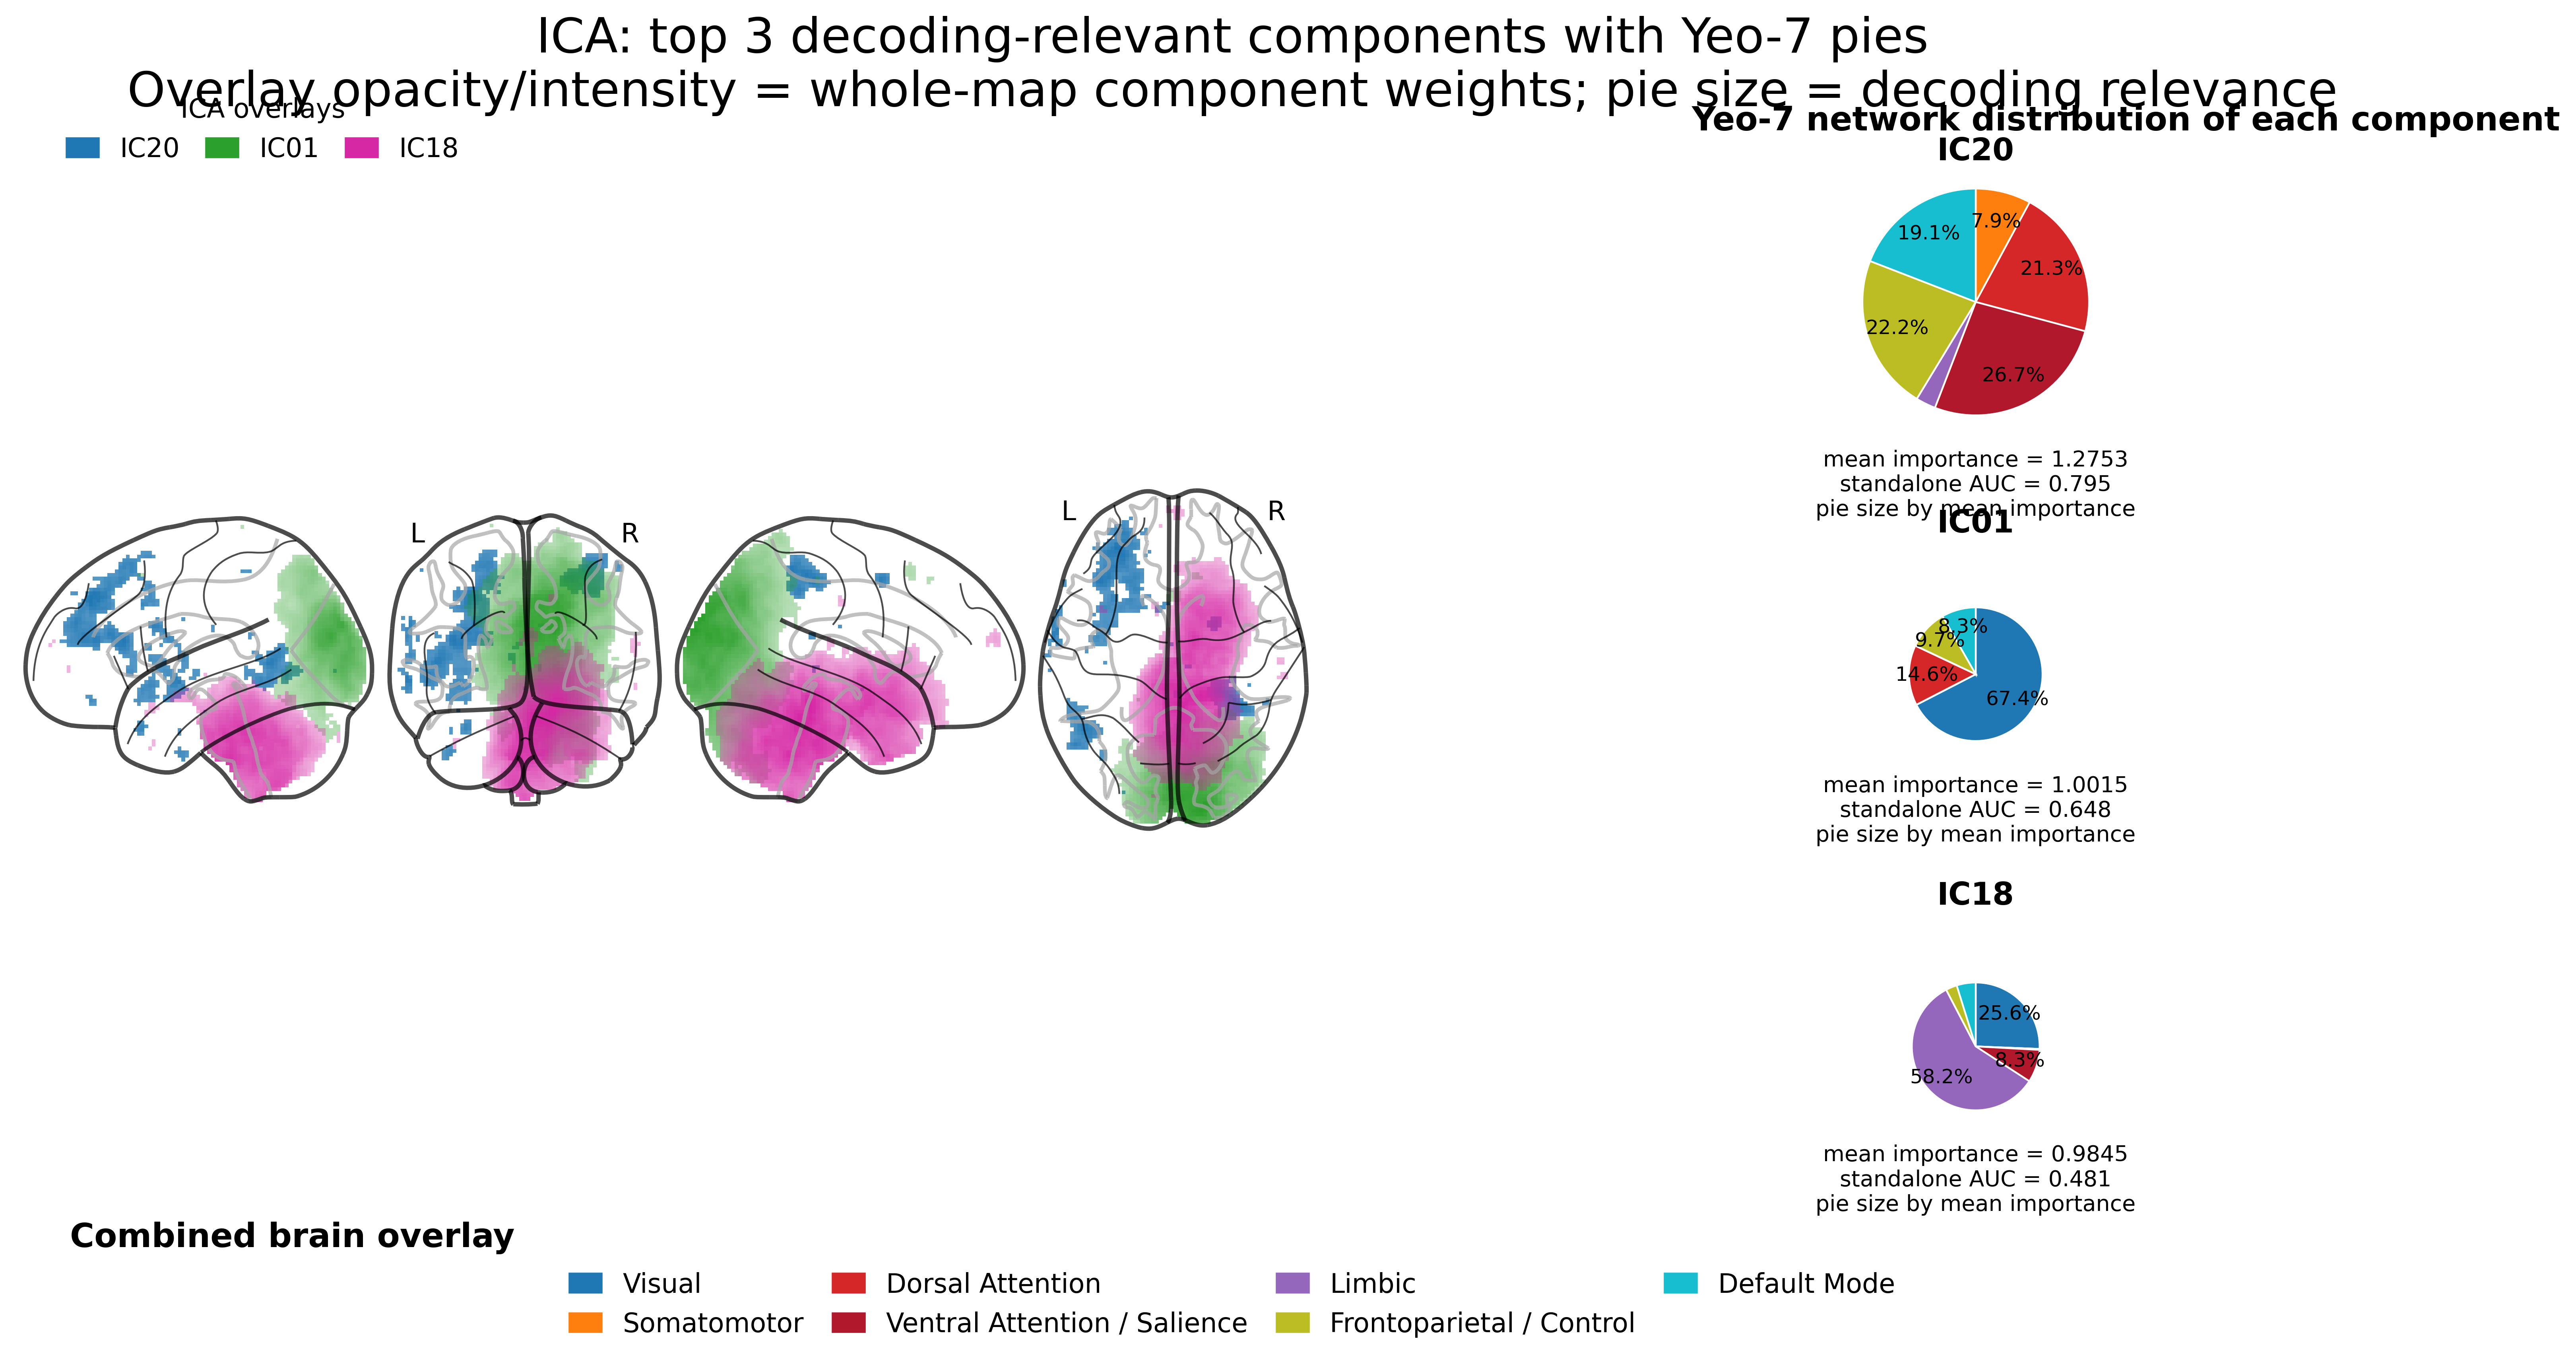

Saved: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA/paper_figures_ica_overlay_top3_component_pies/ica_overlay_top3_components_with_pies.png
Saved: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA/paper_figures_ica_overlay_top3_component_pies/ica_overlay_top3_components_with_pies.pdf


In [5]:

# Choose how pie size is scaled
if PIE_SIZE_BY == "standalone_auc":
    size_values = top_df["standalone_auc_mean"].to_numpy()
    size_label = "standalone AUC"
else:
    size_values = top_df["mean_importance"].to_numpy()
    size_label = "mean importance"

pie_radii = scale_to_radius(size_values, radius_min=PIE_RADIUS_MIN, radius_max=PIE_RADIUS_MAX)

fig = plt.figure(figsize=FIGSIZE, dpi=DPI)

# ----- Combined brain overlay -----
display_obj = plotting.plot_glass_brain(
    stat_map_img=None,
    display_mode=DISPLAY_MODE,
    black_bg=False,
    colorbar=False,
    figure=fig,
    axes=BRAIN_AXES_RECT,
)

labels_and_colors = []
for idx, row in top_df.iterrows():
    comp = int(row["component"])
    label = row["label"]
    color_hex = row["overlay_color"]
    overlay_img = component_overlay_img(
        component_img_4d=component_img,
        component_idx_1based=comp,
        mask_bool=mask_bool,
        use_abs=USE_ABSOLUTE_COMPONENT_MAPS,
    )
    cmap = make_alpha_cmap(color_hex, name=f"ica_{label}_alpha")
    display_obj.add_overlay(overlay_img, cmap=cmap, vmin=0.0, vmax=1.0)
    labels_and_colors.append((label, color_hex))

# ----- Pie charts -----
for idx, row in top_df.iterrows():
    comp = int(row["component"])
    label = row["label"]
    pie_df = (
        network_df[network_df["component"] == comp]
        .sort_values("network_id")
        .reset_index(drop=True)
    )

    ax = fig.add_axes([PIE_X, PIE_BOTTOMS[idx], PIE_WIDTH, PIE_HEIGHT])
    subtitle_lines = []
    if SHOW_IMPORTANCE_TEXT:
        subtitle_lines.append(f"mean importance = {row['mean_importance']:.4f}")
    if SHOW_STANDALONE_AUC and pd.notnull(row["standalone_auc_mean"]):
        subtitle_lines.append(f"standalone AUC = {row['standalone_auc_mean']:.3f}")
    subtitle_lines.append(f"pie size by {size_label}")

    add_pie(
        ax=ax,
        pie_df=pie_df,
        radius=float(pie_radii[idx]),
        title=label,
        subtitle="\n".join(subtitle_lines),
    )

# ----- Titles and legends -----
fig.suptitle(
    "ICA: top 3 decoding-relevant components with Yeo-7 pies\n"
    "Overlay opacity/intensity = whole-map component weights; pie size = decoding relevance",
    fontsize=22,
    y=0.97,
)

fig.text(0.07, 0.11, "Combined brain overlay", fontsize=15, fontweight="bold")
fig.text(PIE_X + 0.03, 0.89, "Yeo-7 network distribution of each component", fontsize=15, fontweight="bold")

add_component_legend(fig, labels_and_colors)
add_network_legend(fig)

outfile_png = OUTDIR / "ica_overlay_top3_components_with_pies.png"
outfile_pdf = OUTDIR / "ica_overlay_top3_components_with_pies.pdf"
fig.savefig(outfile_png, bbox_inches="tight")
fig.savefig(outfile_pdf, bbox_inches="tight")
plt.show()

print("Saved:", outfile_png)
print("Saved:", outfile_pdf)



## How to interpret this figure

- The **brain panel** overlays the **top 3 ICA components** in different colors on the same glass brain.
- Within each color, darker / more opaque regions indicate **larger whole-map component weights**.
- Each **pie chart** shows the **Yeo-7 distribution** of that individual component using the **whole component map**.
- The **pie size** reflects **decoding relevance**, not spatial extent.

### What the annotations mean
- **mean importance**: contribution of that component to the full repeated-CV decoding model
- **standalone AUC**: repeated-CV AUC when using only that component's static features

### Important caveat
A component can have:
- a **large pie** because it is very important for decoding,
- but still have a **mixed Yeo distribution** if it spans several networks.

So:
- **pie size** answers: *how relevant is this component for decoding?*
- **pie slices** answer: *which networks make up this component spatially?*
